# Week 4 - Model Evaluation
## AI-Based Chocolate Paan Sales Prediction System Using Machine Learning

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
df=pd.read_excel('Chocolate_Paan_Sales_Dataset_10000.xlsx')
df.head()

,Date,Day_of_Week,Month,Weekend,Festival,Season,Temperature,Rainfall,Price,Discount_Percentage,Instagram_Reel,YouTube_Video,Facebook_Ads,Marketing_Budget,Returning_Customers,New_Customers,Online_Orders,Offline_Orders,Customer_Rating,Boxes_Sold
0,2024-01-01,Monday,1,0,0,Winter,28.3,10.0,120,0,1,0,1,3175,119,51,22,102,4.2,160
1,2024-01-02,Tuesday,1,0,0,Winter,24.0,16.9,100,10,0,1,1,2565,80,34,33,37,4.5,172
2,2024-01-03,Wednesday,1,0,0,Winter,24.9,17.8,110,10,1,0,0,3972,105,58,79,36,4.7,181
3,2024-01-04,Thursday,1,0,1,Winter,24.0,13.8,140,15,1,0,0,1212,116,43,45,102,4.3,237
4,2024-01-05,Friday,1,0,0,Winter,20.5,2.8,110,10,1,1,0,1357,14,44,65,110,3.8,170


In [4]:
X=df[['Temperature','Price','Discount_Percentage','Marketing_Budget','Instagram_Reel','YouTube_Video','Facebook_Ads','Returning_Customers','New_Customers','Online_Orders','Offline_Orders','Customer_Rating','Festival','Weekend']]
y=df['Boxes_Sold']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [5]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(mae,mse,rmse,r2)

7.7101645860720565 79.7160847235617 8.928386456889157 0.9448978555227474


In [6]:
train_score=model.score(X_train,y_train)
test_score=model.score(X_test,y_test)
print(train_score,test_score)

0.940213098114674 0.9448978555227474


In [10]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training R² Score :", train_score)
print("Testing R² Score :", test_score)

difference = abs(train_score - test_score)

print("Difference :", difference)

if difference <= 0.05:
    print("Model is Well Fitted")
elif train_score > test_score:
    print("Model is Overfitting")
else:
    print("Model is Underfitting")

Training R² Score : 0.940213098114674
Testing R² Score : 0.9448978555227474
Difference : 0.004684757408073392
Model is Well Fitted


In [7]:
result=pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})
result.head(10)

,Actual,Predicted
0,174,188.242607
1,117,124.386696
2,146,152.518891
3,181,185.526567
4,102,98.837187
5,115,113.298408
6,166,161.168424
7,101,88.986947
8,167,152.363851
9,156,160.880623


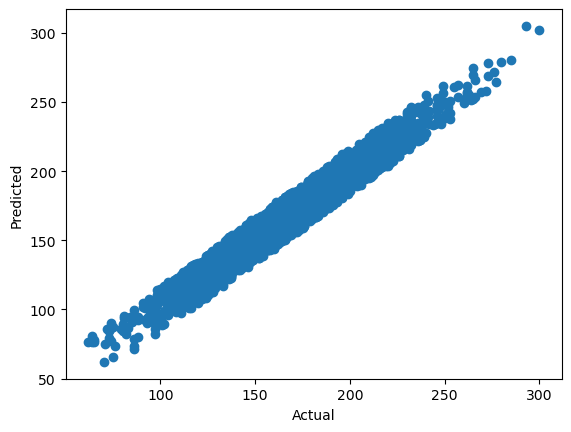

In [8]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

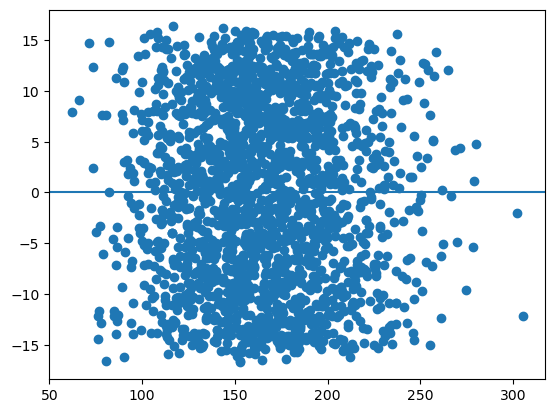

In [9]:
residuals=y_test-y_pred
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.show()